# Netflix catalogue: exploratory data analysis

**Questions:**
1. How fast did the catalogue grow, and how does the mix of movies and TV shows differ?
2. Who is the content for, and which genres dominate?
3. Where does the content come from?
4. How long are movies, and how many seasons do shows run?
5. How new is the content when it arrives on Netflix?

**Data:** 8,807 titles (snapshot up to September 2021). Cleaning is in `netflix_data.py` and is summarised below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import netflix_data as nd

pd.set_option("display.max_columns", 30)
df = nd.load_titles()
print(df.shape)
df[["type", "title", "country", "date_added", "release_year", "rating", "audience", "duration", "listed_in"]].head()

(8807, 22)


,type,title,country,date_added,release_year,rating,audience,duration,listed_in
0,Movie,Dick Johnson Is Dead,United States,2021-09-25,2020,PG-13,Teens,90 min,Documentaries
1,TV Show,Blood & Water,South Africa,2021-09-24,2021,TV-MA,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,NaN,2021-09-24,2021,TV-MA,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,NaN,2021-09-24,2021,TV-MA,Adults,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,India,2021-09-24,2021,TV-MA,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."


## 0. Data cleaning

- The CSV is UTF-8 apart from one appended row. Reading the whole file as ISO-8859-1 garbled 2,500+ names (e.g. *Raúl*), so that one row was re-encoded to UTF-8.
- 14 completely empty `Unnamed` columns were dropped.
- 3 rows had the movie duration typed into the `rating` column. The values were moved back.
- 2 rows added in 2024 fall outside the September 2021 snapshot and were excluded.
- Ratings (TV-MA, PG-13, ...) describe the **intended audience**, not quality, so they are grouped into audience bands instead of being averaged.

In [2]:
df.isna().sum().loc[lambda s: s > 0].to_frame("missing values")

,missing values
director,2634
cast,825
country,831
date_added,10
rating,7
year_added,10
years_to_netflix,10
minutes,2676
seasons,6131
main_country,831


## 1. Growth and content mix

type
Movie      0.696
TV Show    0.304
Name: proportion, dtype: float64


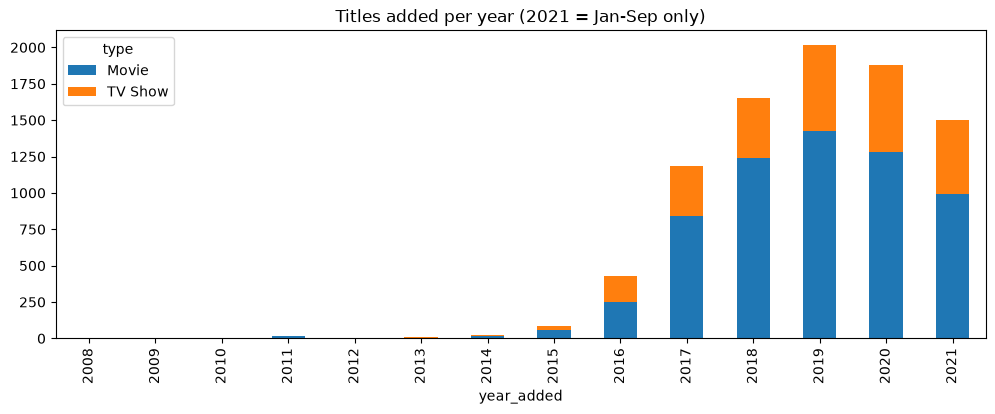

In [3]:
print(df["type"].value_counts(normalize=True).round(3))
added = df.groupby(["year_added", "type"]).size().unstack().loc[2008:]
added.plot.bar(stacked=True, figsize=(12, 4), title="Titles added per year (2021 = Jan-Sep only)")
plt.show()

## 2. Audience and genres

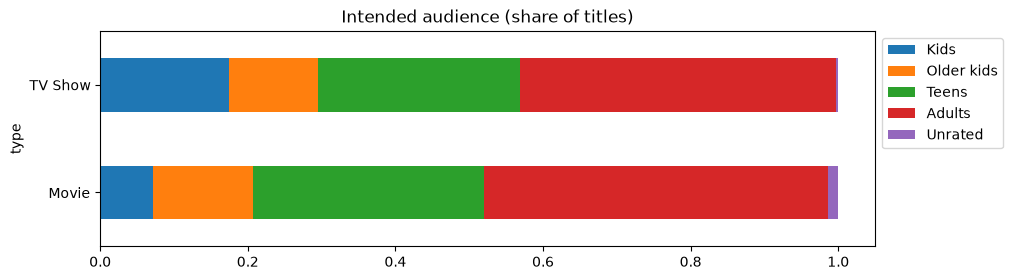

audience,Kids,Older kids,Teens,Adults,Unrated
type,,,,,
Movie,0.072,0.135,0.313,0.467,0.014
TV Show,0.174,0.121,0.274,0.429,0.003


In [4]:
mix = df.groupby("type")["audience"].value_counts(normalize=True).unstack()[nd.AUDIENCE_ORDER]
mix.plot.barh(stacked=True, figsize=(10, 2.8), title="Intended audience (share of titles)")
plt.legend(bbox_to_anchor=(1, 1)); plt.show()
mix.round(3)

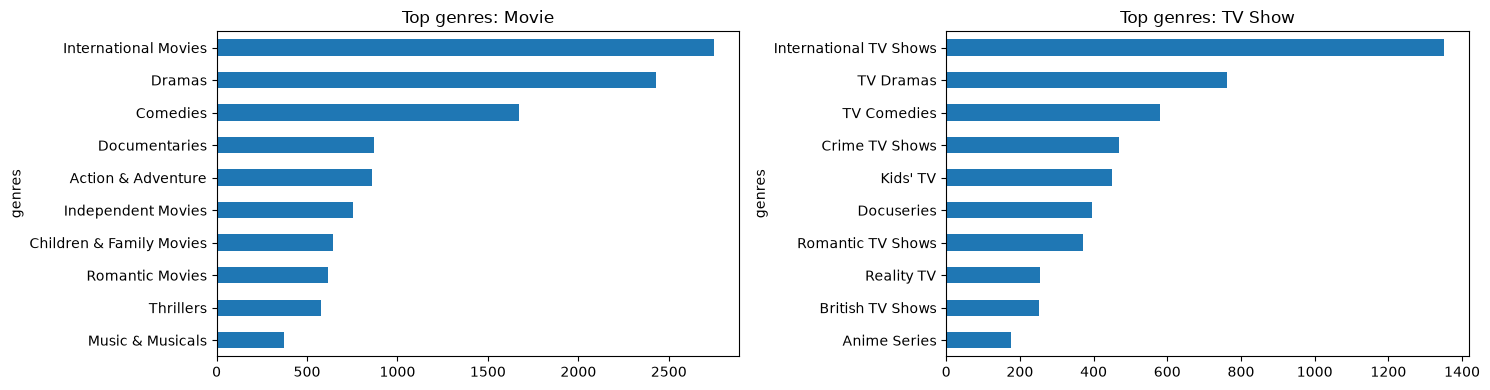

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, kind in zip(axes, ["Movie", "TV Show"]):
    nd.explode_counts(df[df["type"] == kind], "genres", 10).sort_values().plot.barh(ax=ax, title=f"Top genres: {kind}")
plt.tight_layout()

## 3. Where does the content come from?

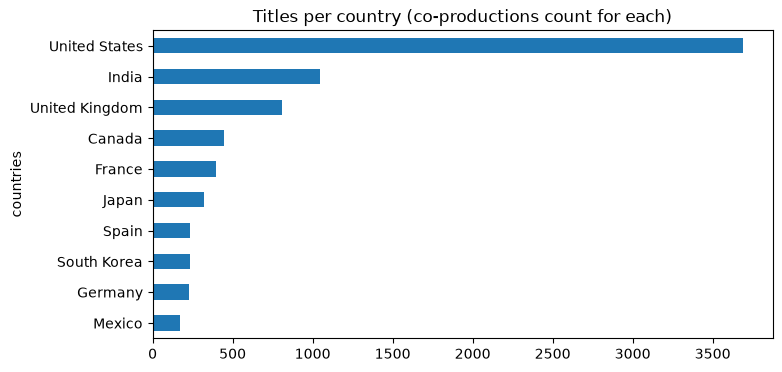

type,Movie,TV Show,movie_share
countries,,,
South Korea,61,170,0.264069
Japan,119,199,0.374214
Mexico,111,58,0.656805
United Kingdom,534,272,0.662531
Canada,319,126,0.716854
Spain,171,61,0.737069
United States,2752,938,0.745799
France,303,90,0.770992
Germany,182,44,0.805310


In [6]:
top = nd.explode_counts(df, "countries", 10)
top.sort_values().plot.barh(figsize=(8, 4), title="Titles per country (co-productions count for each)")
plt.show()
by_type = df.explode("countries").query("countries in @top.index").groupby(["countries", "type"]).size().unstack()
by_type.assign(movie_share=lambda d: d["Movie"] / d.sum(axis=1)).sort_values("movie_share")

## 4. Duration

Median movie length: 98.0 min | TV shows with a single season: 67%


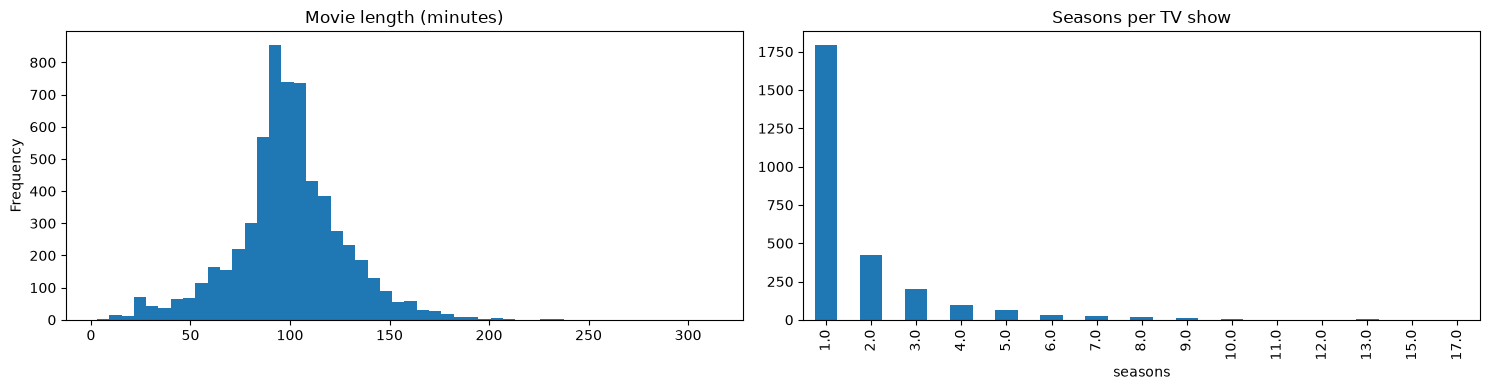

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
df["minutes"].plot.hist(bins=50, ax=axes[0], title="Movie length (minutes)")
df["seasons"].value_counts().sort_index().plot.bar(ax=axes[1], title="Seasons per TV show")
plt.tight_layout()
print("Median movie length:", df["minutes"].median(), "min | TV shows with a single season:",
      f"{(df['seasons'] == 1).sum() / df['seasons'].notna().sum():.0%}")

## 5. How new is the content?

type
Movie      2.0
TV Show    0.0
Name: median years from release to Netflix, dtype: Float64


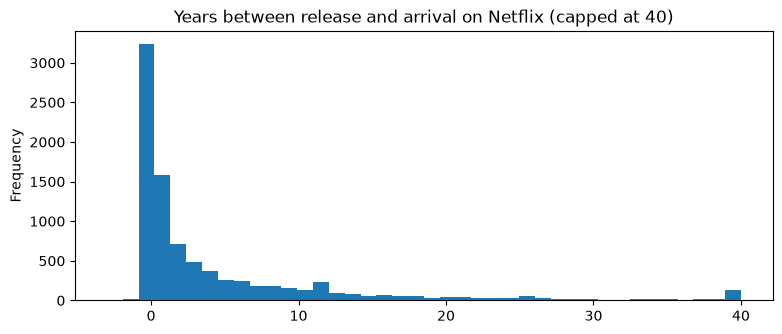

In [8]:
print(df.groupby("type")["years_to_netflix"].median().rename("median years from release to Netflix"))
df["years_to_netflix"].clip(upper=40).plot.hist(bins=40, figsize=(9, 3.5), title="Years between release and arrival on Netflix (capped at 40)")
plt.show()

## 6. People

In [9]:
pd.concat([nd.explode_counts(df, "directors", 10).rename_axis("director").reset_index(name="titles"),
           nd.explode_counts(df, "cast_list", 10).rename_axis("cast member").reset_index(name="titles")], axis=1)

,director,titles,cast member,titles
0,Rajiv Chilaka,22,Anupam Kher,43
1,Jan Suter,21,Shah Rukh Khan,35
2,Raúl Campos,19,Julie Tejwani,33
3,Suhas Kadav,16,Naseeruddin Shah,32
4,Marcus Raboy,16,Takahiro Sakurai,32
5,Jay Karas,15,Rupa Bhimani,31
6,Cathy Garcia-Molina,13,Akshay Kumar,30
7,Youssef Chahine,12,Om Puri,30
8,Martin Scorsese,12,Yuki Kaji,29
9,Jay Chapman,12,Amitabh Bachchan,28


## 7. Conclusions

- **Movies make up 70% of the catalogue.** Additions peaked in **2019 (about 2,000 titles)**, then fell slightly in 2020. The 2021 figure covers only nine months.
- **Adult (TV-MA/R) content is the largest audience group** for both movies (47%) and shows (43%). Kids' content is a much larger share of TV shows (17%) than of movies (7%).
- **International content dominates the genre tags:** "International Movies" and "International TV Shows" are the most common genres.
- **The US contributes the most titles, followed by India.** Indian titles are almost all movies (962 movies vs 84 shows), which explains why Indian actors lead the cast-frequency list.
- The typical movie runs **98 minutes** (IQR 87–114), and **two thirds of TV shows have only one season**.
- Content is fresh: TV shows usually arrive in their release year, and movies about **2 years** after release.

**Limitations:** this is a catalogue snapshot with no viewing data, so popularity can't be measured. Genre and country
tags overlap (one title can have several).